In [1]:
import networkx as nx
import numpy as np
from numpy import linalg
from scipy.sparse import find, csr_matrix, csr_array
from matplotlib import pyplot, patches
import random
import itertools
import matplotlib.pyplot as plt
import time
import collections
from IPython.display import clear_output
import heapq
import pickle
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import math
from collections import deque

np.random.seed(42)
random.seed(10)

# PREFERENTIAL ATTACHMENT GRAPHS

In [2]:
def preferential_attachment_variable_m(
    N: int,
    seed: int | None = None,
    init_nodes: int | None = None,
    init_mode: str = "complete",
    M=(1, 2, 3, 4),
):
    rng = np.random.default_rng(seed)
    M = tuple(M)

    # safety check
    if N < 2:
        raise ValueError("N deve essere >= 2.")

    # numero nodi iniziali
    init_nodes = max(2, min(init_nodes, N))

    # 1) inizializzazione connessa e con gradi > 0
    if init_mode == "complete":
        G = nx.complete_graph(init_nodes)
    else:
        raise ValueError("init_mode deve essere 'complete'")

    # 2) crescita
    for u in range(init_nodes, N):
        G.add_node(u)

        # numero di archi
        m = int(rng.choice(M))
        existing = np.array(list(G.nodes()))
        existing = existing[existing != u]
        m = min(m, len(existing))

        # gradi dei nodi esistenti
        degrees = np.array([G.degree(v) for v in existing], dtype=float)
        s = degrees.sum()

        # probabilità di selezione di ciascun nodo esistente
        probs = degrees / s

        # seleziona m nodi distinti dall’insieme dei nodi esistenti, usando le probabilità probs
        targets = rng.choice(existing, size=m, replace=False, p=probs)
        for v in targets:
            G.add_edge(u, int(v))

    return G

In [3]:
#Function to assign the trasholds
def assign_thresholds_paper_experiments(
    G: nx.Graph,
    c: int,
    seed: int | None = None,
    attr: str = "theta",
):
    """
    Assign thresholds as in the paper's experiments:
      theta(v) uniformly random from {max(2,c), 2c, 3c, ..., ceil(n/c)*c}
    where n is the number of nodes (paper uses n=200).
    Stores thresholds in G.nodes[v][attr] and returns a dict {v: theta(v)}.
    """
    if c <= 0:
        raise ValueError("c must be a positive integer.")

    rng = np.random.default_rng(seed)
    n = G.number_of_nodes()

    k_max = math.ceil(n / c)
    values = list(range(max(2, c), k_max * c + 1, c))  # max(2,c), 2c, 3c, ..., ceil(n/c)*c

    theta = {v: int(rng.choice(values)) for v in G.nodes()}
    nx.set_node_attributes(G, theta, name=attr)
    return theta

In [4]:
def history_to_np(history, max_calls):
  x = np.zeros(max_calls)
  t = 0
  temp = history[0][0]
  for i in range(max_calls):
    if history[t][1] == i+1:
      temp = history[t][0]
      if t != len(history)-1:
        t+=1
    x[i] = temp
  return x

# Define Diffusion Model

In [5]:
def connected_component_threshold_update_theta(g, active_mask, theta_vec):
    """
    One propagation step under the rule:
    v (inactive) becomes active iff the total number of currently-active nodes
    reachable via active-only paths from v is >= theta_vec[v].

    A logical vector containing a value 1 for all the nodes that are newly activated at this iteration is returned

    Implementation detail:
      - Build components on the ACTIVE subgraph only.
      - For an inactive v, find the set of DISTINCT active components that 'touch' v
        (i.e., v has at least one neighbor inside that component).
      - Sum the sizes of those DISTINCT components; activate if sum >= theta_vec[v].
      - This allows the active nodes to be spread across many disjoint components.
    """
    N = g.number_of_nodes()
    newly_active = np.zeros(N, dtype=bool)

    # If no active nodes exist, nothing can activate
    if not np.any(active_mask):
        return newly_active

    #extract active subgraph + its connected components
    active_nodes = np.flatnonzero(active_mask)
    H = g.subgraph(active_nodes)

     #Label each active node with its component ID and record component sizes
    # map active node -> component id (integer)
    comp_id_of = {}
    comp_sizes = []
    cid = 0
    active_set = set(active_nodes)

    visited = set()
    for u in active_nodes:
        if u in visited:
            continue
        # BFS/DFS to gather all nodes in this connected component
        stack = [u]
        visited.add(u)
        comp_nodes = [u]
        while stack:
            x = stack.pop()
            for nbr in g.neighbors(x):
                if nbr in active_set and nbr not in visited:
                    visited.add(nbr)
                    stack.append(nbr)
                    comp_nodes.append(nbr)
        size = len(comp_nodes)
        comp_sizes.append(size)
        for w in comp_nodes:
            comp_id_of[w] = cid
        cid += 1
    comp_sizes = np.asarray(comp_sizes, dtype=int)
    # After BFS, record size and assign labels
    # now test inactive nodes
    inactive_nodes = np.flatnonzero(~active_mask)
    for v in inactive_nodes:
        touched_cids = set()    # which active components v touches
        for u in g.neighbors(v):
            if active_mask[u]:
                c = comp_id_of.get(u, None)
                if c is not None:
                    touched_cids.add(c)
         # Sum the sizes of all distinct active components connected to v
        if touched_cids:
            total_reachable = int(comp_sizes[list(touched_cids)].sum())
            if total_reachable >= int(theta_vec[v]-1):
                newly_active[v] = True

    return newly_active

In [6]:
def Influence_evaluation_comp_threshold_theta(
    g, W, x0, params=None, max_t=999, *, theta_vec, h0=1.0
):
    """
    Simulate the full influence cascade to steady state.

    Parameters
    ----------
    g : networkx.Graph
    W : np.ndarray (not used, kept for API compatibility)
    x0 : np.ndarray[float]
        Initial activation vector (positive values = active seeds).
    params : list (unused placeholder for compatibility)
    max_t : int
        Maximum number of propagation steps.
    theta_vec : np.ndarray[int]
        Per-node activation thresholds θ_i.
    h0 : float
        Activation value to assign to active nodes in the final vector.

    Returns
    -------
    final_spread : int
        Total number of active nodes at convergence.
    spread_hist : list[int]
        Cumulative number of active nodes at each time step.
    [final_x] : list of np.ndarray
        Final activation vector (values = h0 for active nodes, 0 otherwise).

    Notes
    -----
    Runs iterative updates until the set of active nodes stops changing.
    """
    N = g.number_of_nodes()

    # Initialize with seeds: nodes where x0 > 0 are active
    active = (x0 > 0).astype(bool)
    spread_hist = [int(np.sum(active))]

    for _ in range(max_t):
        prev = active.copy()
        # Apply one activation step
        newly = connected_component_threshold_update_theta(g, prev, theta_vec)
        # Merge new activations
        active = prev | newly
        # Stop if nothing changed (steady state)
        if np.array_equal(active, prev):
            break
        spread_hist.append(int(np.sum(active)))

    final_spread = int(np.sum(active))
    final_x = np.zeros(N, dtype=float)
    final_x[active] = h0
    return final_spread, spread_hist, [final_x]

In [7]:

def assign_thresholds_paper_experiments(G: nx.Graph, c: int, seed: int | None = None, attr: str = "theta"):
    """
    theta(v) uniformly random from {max(2,c), 2c, 3c, ..., ceil(n/c)*c}
    where n = number of nodes (paper uses n=200).
    Stores in G.nodes[v][attr] and returns (theta_dict, allowed_values).
    """
    if c <= 0:
        raise ValueError("c must be a positive integer.")
    rng = np.random.default_rng(seed)
    n = G.number_of_nodes()

    k_max = math.ceil(n / c)
    allowed_values = list(range(max(2, c), k_max * c + 1, c))

    theta = {v: int(rng.choice(allowed_values)) for v in G.nodes()}
    nx.set_node_attributes(G, theta, name=attr)
    return theta, allowed_values



# Define the NS-solver

Questo è l'NS standard. E' copito e incollato dal github vostro, con il nuovo modello di diffusione, ed è quello che avevi controllato durante le vacanze di natale, quindi dovremmo avere esattamente la stessa versione.

In [8]:
def NS_solver(g, thetas, x0, delta, xi, d, max_time, buffer_dim, verbose=0):
    n_nodes = len(x0)
    x_hist = [np.array(x0, dtype=float)]
    s_hist = [connected_component_spread(g, x0, thetas=thetas, max_t=1000)[0]]
    r = 0
    xi_t = xi
    stop = False
    buffer = collections.deque(maxlen=buffer_dim)
    calls = 1
    start = time.perf_counter()
    history = [[s_hist[-1], time.perf_counter() - start, calls]]

    def print_status(spread, done=False):
        if not verbose:
            return
        msg = (
            f"Neighbors search... Done! Calls:{calls}. Time: {round(time.perf_counter()-start)}/{max_time} s. "
            f"Influence spread: {spread}."
            if done
            else f"Neighbors search... Calls:{calls}. Time: {round(time.perf_counter()-start)}/{max_time} s. "
            f"Influence spread: {spread}."
        )
        print("\r" + msg + " " * 10, end="" if not done else None)

    def evaluate_neighbors(neighbors, s_base, x_base):
        nonlocal calls, stop
        s_temp = s_base
        x_temp = x_base

        for elem in neighbors:
            x_elem = np.zeros(n_nodes)
            x_elem[list(elem)] = 1.0
            key = tuple(x_elem)

            if key in buffer:
                continue
            if time_exceeded(start, max_time):
                stop = True
                break

            s_elem = connected_component_spread(g, x_elem, thetas=thetas, max_t=1000)[0]
            buffer.append(key)
            calls += 1
            print_status(s_temp)

            if s_elem > s_temp:
                history.append([s_elem, time.perf_counter() - start, calls])
                x_temp = x_elem
                s_temp = s_elem

                if s_elem == n_nodes:
                    return True, x_temp, s_temp
                if s_temp > (1 + xi_t) * s_base:
                    break

        return False, x_temp, s_temp

    print_status(s_hist[-1])

    if s_hist[-1] == n_nodes:
        print_status(s_hist[-1], done=True)
        return s_hist, x_hist, history

    while (not stop) and (r < 1000):
        if time_exceeded(start, max_time):
            break

        idx = set(np.nonzero(x_hist[-1])[0])
        neighbors = []

        for elem1 in idx:
            for elem2 in set(g.neighbors(elem1)) - idx:
                temp = idx.copy()
                temp.add(elem2)
                temp.remove(elem1)
                neighbors.append(temp)

        found_opt, x_temp, s_temp = evaluate_neighbors(neighbors, s_hist[-1], x_hist[-1])
        if found_opt:
            x_hist.append(x_temp)
            s_hist.append(s_temp)
            print_status(s_hist[-1], done=True)
            return s_hist, x_hist, history

        x_hist.append(x_temp)
        s_hist.append(s_temp)
        r += 1

        if s_hist[-1] > (1 + xi_t) * s_hist[-2]:
            continue
        if s_hist[-1] > s_hist[-2]:
            xi_t *= delta
            continue

        x_hist.pop()
        s_hist.pop()

        idx = set(np.nonzero(x_hist[-1])[0])
        idx_temp = set(range(n_nodes)) - idx
        neighbors = []

        for i in range(d // 2):
            for elem1 in itertools.combinations(idx, len(idx) - 1 - i):
                for elem2 in itertools.combinations(idx_temp, i + 1):
                    neighbors.append(list(set(elem1) | set(elem2)))

        found_opt, x_temp, s_temp = evaluate_neighbors(neighbors, s_hist[-1], x_hist[-1])
        if found_opt:
            x_hist.append(x_temp)
            s_hist.append(s_temp)
            print_status(s_hist[-1], done=True)
            return s_hist, x_hist, history

        x_hist.append(x_temp)
        s_hist.append(s_temp)
        r += 1

        if s_hist[-1] == s_hist[-2]:
            x_hist.pop()
            s_hist.pop()
            stop = True
        elif s_hist[-1] <= (1 + xi_t) * s_hist[-2]:
            xi_t *= delta

    history.append([s_hist[-1], time.perf_counter() - start, calls])
    print_status(s_hist[-1], done=True)
    return s_hist, x_hist, history


def NS_technology_diffusion_binary_search(g, thetas, strategy, delta, xi, d, max_time, buffer_dim, verbose=0):
    start = time.perf_counter()
    n_nodes = g.number_of_nodes()
    tried_k = set()
    best_k = None
    best_solution_x = None
    top_k, bottom_k = n_nodes, 1
    time_single = max_time / max(1, math.ceil(math.log2(n_nodes)))
    times = {}
    strategy_tried = {}
    temp_x = {}

    while bottom_k <= top_k and time.perf_counter() - start < max_time:
        k = (top_k + bottom_k) // 2
        if k in tried_k:
            break
        tried_k.add(k)

        x = strategy[0](g, n_nodes, k, thetas=thetas, connected=1)
        s, final_x, history = Neighbor_Search(g, thetas, x, delta, xi, d, time_single, buffer_dim, verbose=0)
        spread = s[-1]
        x_last = np.array(final_x[-1], dtype=float)
        times[k] = history[-1][1]
        strategy_tried[k] = -1 if times[k] < 0.9 * time_single else 0
        if strategy_tried[k] == -1:
            temp_x[k] = x_last

        if spread == n_nodes:
            if best_k is None or k < best_k:
                best_k = k
                best_solution_x = x_last.copy()
            top_k = k - 1
        else:
            inferred_success_k = k + (n_nodes - spread)
            if best_k is None or inferred_success_k < best_k:
                _, _, active_after = connected_component_spread(g, x_last, thetas, max_t=1000)
                inferred_x = x_last.copy()
                inferred_x[np.where(active_after == 0)[0]] = 1.0
                best_k = inferred_success_k
                best_solution_x = inferred_x

            if inferred_success_k <= top_k:
                top_k = inferred_success_k - 1
            bottom_k = k + 1

    random.seed(42)
    while time.perf_counter() - start < max_time and best_k is not None and best_k > 1:
        k = best_k - 1
        if strategy_tried.get(k) is None:
            strat = 0
            x = strategy[strat](g, n_nodes, k, thetas=thetas, connected=1)
        elif strategy_tried[k] == -1:
            strat = 0
            x = temp_x[k]
        else:
            strat = min(len(strategy) - 1, strategy_tried[k] + 1)
            x = strategy[strat](g, n_nodes, k, thetas=thetas, connected=1)

        remaining = max_time - (time.perf_counter() - start)
        if remaining <= 0:
            break

        s, final_x, _ = Neighbor_Search(
            g, thetas, x, delta, xi, d, min(time_single, remaining), buffer_dim, verbose=0
        )
        strategy_tried[k] = strat

        if s[-1] == n_nodes:
            best_k = k
            best_solution_x = np.array(final_x[-1], dtype=float)
        else:
            break

    return best_k, best_solution_x, time.perf_counter() - start

# NS_last

In [9]:

def NS_last(
    g: nx.Graph,
    x0: np.ndarray,
    theta_vec: np.ndarray,
    *,
    d: int = 2,
    max_time: int = 120,
    buffer_dim: int = 5000,
    max_outer_iters: int = 1000,
    early_stop_spread: int | None = None,
    H_RADIUS: int = 30,
):


    N = len(x0)
    theta_vec = np.asarray(theta_vec, dtype=int)

    if early_stop_spread is None:
        early_stop_spread = N

    # numero di seed iniziali
    K = int(np.count_nonzero(x0))
    min_conn_req = K

    def x_from_seedset(S: set[int]) -> np.ndarray:
        x = np.zeros(N, dtype=float)
        x[list(S)] = 1.0
        return x

    def max_comp_size_in_seedset(S: set[int]) -> int:
        if len(S) <= 1:
            return len(S)
        sub = g.subgraph(S)
        return max((len(c) for c in nx.connected_components(sub)), default=0)

    def meets_min_connectedness(S: set[int]) -> bool:
        return max_comp_size_in_seedset(S) >= min_conn_req

  #usiamo questa funzione per fillare i gap per i nodi considerati a distanza maggiore di 1
  #è abbastanza costosa dovendo calcolare lo shortest path dal seedst
    def make_move(S: set[int], v: int) -> set[int] | None:
        """
        Dato il seedset corrente S (|S| = K) e un candidato v,
        costruisce un nuovo seedset S_new:

        - include v
        - è connesso nel sottografo indotto
        - ha cardinalità K
        - è ottenuto:
            * prendendo tutti i nodi di un cammino più corto tra v e S
            * riempiendo con nodi di S che non rompono la connettività
        """
        v = int(v)
        if v in S:
            # già seed, non serve
            return None

        # Trova il nodo di S più vicino a v e il cammino più corto
        try:
            lengths = nx.single_source_shortest_path_length(g, v)
        except Exception:
            return None

        candidates = [(lengths[u], u) for u in S if u in lengths]
        if not candidates:
            return None

        _, u_best = min(candidates, key=lambda t: t[0])

        try:
            path = nx.shortest_path(g, v, u_best)
        except nx.NetworkXNoPath:
            return None

        path_nodes = set(int(u) for u in path)

        # Se il cammino da solo richiede più di K nodi, non è fattibile
        if len(path_nodes) > K:
            return None

        # Core connesso iniziale: tutti i nodi del cammino
        S_new = set(path_nodes)

        # Possiamo ancora aggiungere nodi dell'old seedset
        remaining = list(S - S_new)

        # Riempiamo fino a K, aggiungendo solo nodi che mantengono la connettività
        while len(S_new) < K:
            added = False
            for u in list(remaining):
                # aggiungi u solo se ha almeno un vicino già in S_new
                for w in g.neighbors(u):
                    if int(w) in S_new:
                        S_new.add(int(u))
                        remaining.remove(u)
                        added = True
                        break
                if added:
                    break
            if not added:
                # non possiamo più aggiungere nodi senza creare componenti isolate
                break

        # se non siamo arrivati a K, scartiamo la move
        if len(S_new) != K:
            return None

        # sicurezza: controlla che sia connesso nell'indotto
        sub = g.subgraph(S_new)
        if not nx.is_connected(sub):
            return None

        return S_new

    # Stato iniziale
    X = [np.array(x0, dtype=float)]
    s0 = influence_evaluation(g, X[-1], theta_vec)[0]
    s = [s0]

    buffer = collections.deque(maxlen=buffer_dim)
    buffer.append(list(X[-1]))

    calls = 1
    start = time.perf_counter()
    r = 0
    stop = False

    history = [[s[-1], 0.0, calls]]

    while not stop and r < max_outer_iters:
        idx = set(np.nonzero(X[-1])[0])  # seedset corrente S
        improved = False

        for u_sel in list(idx):
            # raggio massimo: min tra H_RADIUS, K e N-1
            h = min(H_RADIUS, K, g.number_of_nodes() - 1)

            visited = {int(u_sel)}
            frontier = {int(u_sel)}

            mg_memory = deque(maxlen=5)
            tried_add_nodes = set()

            for radius in range(1, h + 1):
                next_frontier = set()
                for u in frontier:
                    for v in g.neighbors(u):
                        v = int(v)
                        if v not in visited:
                            next_frontier.add(v)

                if not next_frontier:
                    break

                visited |= next_frontier
                frontier = next_frontier

                cand = [v for v in frontier if v not in idx]
                if not cand:
                    mg_memory.append([])
                    continue

                layer_entries = []
                for v in cand:
                    mg_v = 0
                    for w in g.neighbors(v):
                        if theta_vec[int(w)] <= radius:
                            mg_v += 1
                    layer_entries.append((int(mg_v), int(v)))

                # ordina per margine decrescente, poi per id crescente
                layer_entries.sort(key=lambda t: (t[0], -t[1]), reverse=True)
                mg_memory.append(layer_entries)

                # migliore nel livello corrente
                best_current = None
                for mg_v, v in layer_entries:
                    if v not in tried_add_nodes:
                        best_current = (mg_v, v)
                        break

                if best_current is None:
                    continue

                # migliore globale negli ultimi livelli
                best_overall = None
                for entries in mg_memory:
                    for mg_v, v in entries:
                        if v in tried_add_nodes:
                            continue
                        if (
                            best_overall is None
                            or mg_v > best_overall[0]
                            or (mg_v == best_overall[0] and v < best_overall[1])
                        ):
                            best_overall = (mg_v, v)

                attempt_list = []
                if best_overall is not None:
                    attempt_list.append(best_overall[1])
                if best_current is not None and best_current[1] not in attempt_list:
                    attempt_list.append(best_current[1])

                for best_v in attempt_list:
                    best_v = int(best_v)
                    if best_v in tried_add_nodes:
                        continue
                    tried_add_nodes.add(best_v)

                    # NUOVA LOGICA: costruisci una move connessa che includa best_v
                    S_new = make_move(idx, best_v)
                    if S_new is None:
                        continue

                    x_prov = x_from_seedset(S_new)
                    if list(x_prov) in buffer:
                        continue

                    if time.perf_counter() - start >= max_time:
                        stop = True
                        break

                    s_prov = influence_evaluation(g, x_prov, theta_vec)[0]
                    buffer.append(list(x_prov))
                    calls += 1

                    if s_prov > s[-1]:
                        X.append(x_prov)
                        s.append(s_prov)
                        history.append([s_prov, time.perf_counter() - start, calls])
                        improved = True

                        if s_prov >= early_stop_spread:
                            stop = True
                        break

                if stop or improved:
                    break

            if stop or improved:
                break

        # Fase di vicinato combinatorio come fallback, invariata
        if not stop and not improved:
            idx = set(np.nonzero(X[-1])[0])
            idx_temp = set(range(N)) - idx
            neighbors = []

            for i in range(d // 2):
                for rem in itertools.combinations(idx, len(idx) - 1 - i):
                    for add in itertools.combinations(idx_temp, i + 1):
                        neighbors.append(set(rem) | set(add))

            s_temp = s[-1]
            x_temp = X[-1]

            for S_new in neighbors:
                if not meets_min_connectedness(S_new):
                    continue

                x_new = x_from_seedset(S_new)
                if list(x_new) in buffer:
                    continue

                if time.perf_counter() - start >= max_time:
                    stop = True
                    break

                s_new = influence_evaluation(g, x_new, theta_vec)[0]
                buffer.append(list(x_new))
                calls += 1

                if s_new > s_temp:
                    s_temp = s_new
                    x_temp = x_new
                    history.append([s_new, time.perf_counter() - start, calls])
                    if s_new >= early_stop_spread:
                        stop = True
                    break

            if not stop:
                if s_temp > s[-1]:
                    X.append(x_temp)
                    s.append(s_temp)
                else:
                    stop = True

        r += 1

        if time.perf_counter() - start >= max_time:
            stop = True

    history.append([s[-1], time.perf_counter() - start, calls])
    return s, X, history

# NS_Matteo

In [10]:
def _max_comp_size_in_seedset(g, seedset):
    if len(seedset) == 0:
        return 0
    if len(seedset) == 1:
        return 1
    sub = g.subgraph(seedset)
    return max((len(c) for c in nx.connected_components(sub)), default=0)


def _meets_min_connectedness(g, seedset, min_conn_req):
    return _max_comp_size_in_seedset(g, seedset) >= int(min_conn_req)


def _x_from_seedset(n_nodes, seedset):
    x = np.zeros(n_nodes)
    x[list(seedset)] = 1.0
    return x


def _seedset_from_x(x):
    return set(np.nonzero(x)[0])


def _print_ns_status(verbose, calls, start, max_time, spread, done=False):
    if not verbose:
        return
    if done:
        print(
            "\r"
            + f"Neighbors search... Done! Calls:{calls}. Time: {round(time.perf_counter()-start)}/{max_time} s. "
            + f"Influence spread: {spread}."
            + " " * 20
        )
    else:
        print(
            "\r"
            + f"Neighbors search... Calls:{calls}. Time: {round(time.perf_counter()-start)}/{max_time} s. "
            + f"Influence spread: {spread}."
            + " " * 20,
            end="",
        )


def _generate_swap_neighbors(g, idx):
    neighbors = []
    for elem1 in idx:
        for elem2 in set(g.neighbors(elem1)) - idx:
            temp = idx.copy()
            temp.add(elem2)
            temp.remove(elem1)
            neighbors.append(temp)
    return neighbors


def _generate_d_exchange_neighbors(n_nodes, idx, d):
    neighbors = []
    idx_temp = set(range(n_nodes)) - idx
    for i in range(d // 2):
        for elem1 in itertools.combinations(idx, len(idx) - 1 - i):
            for elem2 in itertools.combinations(idx_temp, i + 1):
                neighbors.append(set(elem1) | set(elem2))
    return neighbors


def _filter_feasible_neighbors(g, neighbors, min_conn):
    return [seedset for seedset in neighbors if _meets_min_connectedness(g, seedset, min_conn)]


def _evaluate_neighbors(
    g,
    thetas,
    neighbors,
    s_base,
    x_base,
    n_nodes,
    xi_t,
    buffer,
    calls,
    stop,
    history,
    start,
    max_time,
    verbose,
    target_spread,
    early_break=True,
):
    s_temp = s_base
    x_temp = x_base

    for elem in neighbors:
        x_elem = _x_from_seedset(n_nodes, elem)
        key = tuple(x_elem)

        if key in buffer:
            continue
        if time_exceeded(start, max_time):
            stop = True
            break

        s_elem = connected_component_spread(g, x_elem, thetas=thetas, max_t=1000)[0]
        buffer.append(key)
        calls += 1
        _print_ns_status(verbose, calls, start, max_time, s_elem, done=False)

        if s_elem > s_temp:
            history.append([s_elem, time.perf_counter() - start, calls])
            x_temp = x_elem
            s_temp = s_elem

            if s_elem == target_spread:
                return True, x_temp, s_temp, calls, stop
            if early_break and s_temp > (1 + xi_t) * s_base:
                break

    return False, x_temp, s_temp, calls, stop


def _make_move_connected_seedset(g, seedset, v, k):
    v = int(v)
    if v in seedset:
        return None

    try:
        lengths = nx.single_source_shortest_path_length(g, v)
    except Exception:
        return None

    candidates = [(lengths[u], u) for u in seedset if u in lengths]
    if not candidates:
        return None

    _, u_best = min(candidates, key=lambda t: t[0])

    try:
        path = nx.shortest_path(g, v, u_best)
    except nx.NetworkXNoPath:
        return None

    path_nodes = set(int(u) for u in path)
    if len(path_nodes) > k:
        return None

    s_new = set(path_nodes)
    remaining = list(seedset - s_new)

    while len(s_new) < k:
        added = False
        for u in list(remaining):
            for w in g.neighbors(u):
                if int(w) in s_new:
                    s_new.add(int(u))
                    remaining.remove(u)
                    added = True
                    break
            if added:
                break
        if not added:
            break

    if len(s_new) != k:
        return None

    sub = g.subgraph(s_new)
    if not nx.is_connected(sub):
        return None

    return s_new


def _mg_phase(
    g,
    thetas,
    idx,
    n_nodes,
    k,
    s_base,
    buffer,
    calls,
    history,
    start,
    max_time,
    verbose,
    target_spread,
    min_conn,
    mg_max_depth,
    mg_size,
    mg_memory_len,
):
    improved_mg = False
    stop = False
    x_temp = _x_from_seedset(n_nodes, idx)
    s_temp = s_base

    h = min(max(1, int(mg_max_depth)), k, g.number_of_nodes() - 1)
    mg_memory = collections.deque(maxlen=max(1, int(mg_memory_len)))
    tried_add_nodes = set()

    for u_sel in list(idx):
        visited = {int(u_sel)}
        frontier = {int(u_sel)}

        for radius in range(1, h + 1):
            next_frontier = set()
            for u in frontier:
                for v in g.neighbors(u):
                    v = int(v)
                    if v not in visited:
                        next_frontier.add(v)

            if not next_frontier:
                break

            visited |= next_frontier
            frontier = next_frontier

            cand = [v for v in frontier if v not in idx]
            if not cand:
                mg_memory.append([])
                continue

            layer_entries = []
            for v in cand:
                mg_v = sum(1 for w in g.neighbors(v) if thetas[int(w)] <= radius)
                layer_entries.append((int(mg_v), int(v)))

            layer_entries.sort(key=lambda t: (t[0], -t[1]), reverse=True)
            mg_memory.append(layer_entries)

            best_current = None
            for mg_v, v in layer_entries:
                if v not in tried_add_nodes:
                    best_current = (mg_v, v)
                    break

            if best_current is None:
                continue

            best_overall = None
            for entries in mg_memory:
                for mg_v, v in entries:
                    if v in tried_add_nodes:
                        continue
                    if (
                        best_overall is None
                        or mg_v > best_overall[0]
                        or (mg_v == best_overall[0] and v < best_overall[1])
                    ):
                        best_overall = (mg_v, v)

            attempt_list = []
            if best_overall is not None:
                attempt_list.append(best_overall[1])
            if best_current is not None and best_current[1] not in attempt_list:
                attempt_list.append(best_current[1])

            for best_v in attempt_list:
                best_v = int(best_v)
                if best_v in tried_add_nodes:
                    continue
                tried_add_nodes.add(best_v)

                s_new = _make_move_connected_seedset(g, idx, best_v, k)
                if s_new is None:
                    continue
                if not _meets_min_connectedness(g, s_new, min_conn):
                    continue

                x_prov = _x_from_seedset(n_nodes, s_new)
                key = tuple(x_prov)

                if key in buffer:
                    continue
                if time_exceeded(start, max_time):
                    stop = True
                    break

                s_prov = connected_component_spread(g, x_prov, thetas=thetas, max_t=1000)[0]
                buffer.append(key)
                calls += 1
                _print_ns_status(verbose, calls, start, max_time, s_prov, done=False)

                if s_prov > s_temp:
                    history.append([s_prov, time.perf_counter() - start, calls])
                    x_temp = x_prov
                    s_temp = s_prov
                    improved_mg = True

                    if s_prov == target_spread:
                        return True, improved_mg, x_temp, s_temp, calls, stop
                    break

            if stop or improved_mg:
                break

        if stop or improved_mg:
            break

    return False, improved_mg, x_temp, s_temp, calls, stop

In [11]:
def NS_matteo(
    g,
    thetas,
    x0,
    delta,
    xi,
    d,
    max_time,
    buffer_dim,
    verbose=0,
    min_conn=10,
    mg_max_depth=2,
    mg_size=20,
    mg_memory_len=5,
):
    n_nodes = len(x0)
    x_hist = [np.array(x0, dtype=float)]

    s_hist = [connected_component_spread(g, x0, thetas=thetas, max_t=1000)[0]]
    r = 0
    xi_t = xi
    target_spread = n_nodes

    k = int(np.count_nonzero(x0))

    stop = False
    buffer = collections.deque(maxlen=buffer_dim)
    calls = 1
    start = time.perf_counter()
    history = [[s_hist[-1], time.perf_counter() - start, calls]]

    _print_ns_status(verbose, calls, start, max_time, s_hist[-1], done=False)

    if s_hist[-1] == target_spread:
        _print_ns_status(verbose, calls, start, max_time, s_hist[-1], done=True)
        return s_hist, x_hist, history

    while (not stop) and (r < 1000):
        if time_exceeded(start, max_time):
            stop = True
            break

        idx = _seedset_from_x(x_hist[-1])

        found_opt, improved_mg, x_temp, s_temp, calls, mg_stop = _mg_phase(
            g,
            thetas,
            idx,
            n_nodes=n_nodes,
            k=k,
            s_base=s_hist[-1],
            buffer=buffer,
            calls=calls,
            history=history,
            start=start,
            max_time=max_time,
            verbose=verbose,
            target_spread=target_spread,
            min_conn=min_conn,
            mg_max_depth=mg_max_depth,
            mg_size=mg_size,
            mg_memory_len=mg_memory_len,
        )
        if mg_stop:
            stop = True
            break

        if found_opt:
            x_hist.append(x_temp)
            s_hist.append(s_temp)
            _print_ns_status(verbose, calls, start, max_time, s_hist[-1], done=True)
            return s_hist, x_hist, history

        if improved_mg:
            x_hist.append(x_temp)
            s_hist.append(s_temp)
            r += 1

            if s_hist[-1] > (1 + xi_t) * s_hist[-2]:
                continue
            if s_hist[-1] > s_hist[-2]:
                xi_t = xi_t * delta
            continue

        neighbors = _generate_swap_neighbors(g, idx)
        neighbors = _filter_feasible_neighbors(g, neighbors, min_conn=min_conn)
        found_opt, x_temp, s_temp, calls, stop = _evaluate_neighbors(
            g,
            thetas,
            neighbors,
            s_hist[-1],
            x_hist[-1],
            n_nodes=n_nodes,
            xi_t=xi_t,
            buffer=buffer,
            calls=calls,
            stop=stop,
            history=history,
            start=start,
            max_time=max_time,
            verbose=verbose,
            target_spread=target_spread,
            early_break=True,
        )

        if found_opt:
            x_hist.append(x_temp)
            s_hist.append(s_temp)
            _print_ns_status(verbose, calls, start, max_time, s_hist[-1], done=True)
            return s_hist, x_hist, history

        x_hist.append(x_temp)
        s_hist.append(s_temp)
        r += 1

        if s_hist[-1] > (1 + xi_t) * s_hist[-2]:
            continue
        if s_hist[-1] > s_hist[-2]:
            xi_t = xi_t * delta
            continue

        x_hist.pop()
        s_hist.pop()

        idx = _seedset_from_x(x_hist[-1])
        neighbors = _generate_d_exchange_neighbors(n_nodes, idx, d)
        neighbors = _filter_feasible_neighbors(g, neighbors, min_conn=min_conn)
        found_opt, x_temp, s_temp, calls, stop = _evaluate_neighbors(
            g,
            thetas,
            neighbors,
            s_hist[-1],
            x_hist[-1],
            n_nodes=n_nodes,
            xi_t=xi_t,
            buffer=buffer,
            calls=calls,
            stop=stop,
            history=history,
            start=start,
            max_time=max_time,
            verbose=verbose,
            target_spread=target_spread,
            early_break=True,
        )

        if found_opt:
            x_hist.append(x_temp)
            s_hist.append(s_temp)
            _print_ns_status(verbose, calls, start, max_time, s_hist[-1], done=True)
            return s_hist, x_hist, history

        x_hist.append(x_temp)
        s_hist.append(s_temp)
        r += 1

        if s_hist[-1] == s_hist[-2]:
            x_hist.pop()
            s_hist.pop()
            stop = True
        elif s_hist[-1] <= (1 + xi_t) * s_hist[-2]:
            xi_t = xi_t * delta

    history.append([s_hist[-1], time.perf_counter() - start, calls])
    _print_ns_status(verbose, calls, start, max_time, s_hist[-1], done=True)
    return s_hist, x_hist, history

# Euristiche

helpers

In [12]:
def time_exceeded(start_time, max_time):
    return max_time is not None and (time.perf_counter() - start_time) > max_time

In [13]:
def make_subset_connected(g, x, use_thetas=0, thetas = None):
    s = set(x)

    while True:
        H = g.subgraph(s)
        comps = list(nx.connected_components(H))

        if len(comps) == 1:
            break

        # pick two components
        C1, C2 = comps[0], comps[1]

        # find shortest path between them in full graph
        u = next(iter(C1))
        v = next(iter(C2))
        path = nx.shortest_path(g, u, v)

        # nodes to add (excluding endpoints already in S)
        to_add = [x for x in path if x not in s]

        # remove same number of arbitrary nodes to keep cardinality fixed
        to_remove = list(s - C1 - C2)[:len(to_add)]
        if use_thetas:
            to_remove = sorted(to_remove, key=lambda x: thetas[x])[:len(to_add)]

        for x in to_remove:
            s.remove(x)
        for x in to_add:
          s.add(x)

    return tuple(sorted(s))

In [14]:
def make_vector(init_seeds, N):
    x0 = np.zeros(N, dtype=float)
    x0[list(init_seeds)] = 1.0
    return x0

In [15]:
def connected_component_update(g, active_mask, thetas):

    N = g.number_of_nodes()
    actives = np.zeros(N, dtype=bool)

    if not np.any(active_mask):
        return actives

    active_nodes = np.flatnonzero(active_mask)
    H = g.subgraph(active_nodes)

    comp_id_of = {}
    comp_sizes = []
    cid = 0
    active_set = set(active_nodes)

    visited = set()
    for u in active_nodes:
        if u in visited:
            continue
        stack = [u]
        visited.add(u)
        comp_nodes = [u]
        while stack:
            x = stack.pop()
            for nbr in g.neighbors(x):
                if nbr in active_set and nbr not in visited:
                    visited.add(nbr)
                    stack.append(nbr)
                    comp_nodes.append(nbr)
        size = len(comp_nodes)
        comp_sizes.append(size)

        for w in comp_nodes:
            comp_id_of[w] = cid

        cid += 1

    comp_sizes = np.asarray(comp_sizes, dtype=int)
    inactive_nodes = np.flatnonzero(~active_mask)

    for v in inactive_nodes:
        touched_cids = set()

        for u in g.neighbors(v):
            if active_mask[u]:
                c = comp_id_of.get(u, None)
                if c is not None:
                    touched_cids.add(c)
        if touched_cids:
            total_reachable = int(comp_sizes[list(touched_cids)].sum())
            if total_reachable >= int(thetas[v]):
                actives[v] = True

    return actives

In [16]:
def connected_component_spread(g, x0, thetas, max_t=1000):

    N = g.number_of_nodes()

    active = (x0 > 0).astype(bool)
    spread_hist = [int(np.sum(active))]

    for _ in range(max_t):
        prev = active.copy()
        new = connected_component_update(g, prev, thetas)
        active = prev | new

        if np.array_equal(active, prev):
            break
        spread_hist.append(int(np.sum(active)))

    final_spread = int(np.sum(active))
    final_x = np.zeros(N, dtype=float)
    final_x[active] = 1.0

    return final_spread, spread_hist, final_x

euristiche


In [17]:
def SingleDiscount(g,thetas, K):

  W1 = nx.to_numpy_array(g)
  idx = []
  ddv = np.sum(W1 > 0, axis=0)
  tv = np.zeros(len(g.nodes))

  for _ in range(K):
    u = int(np.argmax(ddv))
    idx.append(u)
    v = list(np.nonzero(W1[u])[0])
    tv[v] += 1
    ddv[v] = ddv[v] - tv[v]
    ddv[u] = -1
    W1[u, :] = 0
    W1[:, u] = 0

  x = np.zeros(len(g.nodes))
  x[idx] = 1.0

  s = connected_component_spread(g, x, thetas, max_t=1000)[0]

  return s, x

In [18]:
def degree(g, N, K, thetas=None, connected=0):
    degs = np.array([g.degree(v) for v in g.nodes()])
    top_K = np.argsort(-degs)[:K]

    if connected:
        top_K = list(make_subset_connected(g, top_K, use_thetas=1, thetas=thetas))

    return make_vector(top_K, N)

In [19]:
def degree_threshold(g, N, K, thetas=None, connected=0):
    dt = np.array([g.degree(v) for v in g.nodes()])*np.array(list(thetas.values()))
    top_K = np.argsort(-dt)[:K]

    if connected:
        top_K = list(make_subset_connected(g, top_K, use_thetas=1, thetas=thetas))

    return make_vector(top_K, N)

In [20]:
def betweenness(g, N, K, thetas=None, connected=0):
    bets = nx.betweenness_centrality(g)
    bet_values = np.array([bets[v] for v in g.nodes()])
    top_K = np.argsort(-bet_values)[:K]

    if connected:
        top_K = list(make_subset_connected(g, top_K, use_thetas=1, thetas=thetas))

    return make_vector(top_K, N)

In [21]:
def degree_connected(g, N, K, thetas = None, connected = None):
    degs = np.array([g.degree(v) for v in g.nodes()])
    top_K = [np.argsort(-degs)[0]]
    neighbors = set(g.neighbors(top_K[0]))
    for _ in range(1, K):
        candidates = [v for v in g.nodes() if v not in top_K and v in neighbors]
        if not candidates:
            break
        degs = np.array([g.degree(v) for v in candidates])
        top_candidate = candidates[np.argsort(-degs)[0]]
        top_K.append(top_candidate)
        neighbors.update(g.neighbors(top_candidate))
    return make_vector(top_K, N)

# Esperimenti

✅ Output folder: /content/gdrive/MyDrive/influence_results/ns_vs_ns_last/2026-03-10_141248_N1000_c1_t60s
✅ Excel: /content/gdrive/MyDrive/influence_results/ns_vs_ns_last/2026-03-10_141248_N1000_c1_t60s/results.xlsx
Graph built: N=1000, edges=2483, c=1
Heuristics: ['degree', 'degree_connected', 'degree_threshold', 'betweenness', 'SingleDiscount', 'random']
K_SEEDS=50 | MAX_TIME=60s
✅ Saved: /content/gdrive/MyDrive/influence_results/ns_vs_ns_last/2026-03-10_141248_N1000_c1_t60s/results.xlsx


,run_id,trial,start_heuristic,heur_spread,NS_best_spread,NS_calls,NS_matteo_best_spread,NS_matteo_calls,NS_last_best_spread,NS_last_calls,N,E,C_THRESH,K,trial_seed
0,2026-03-10_141248,1,degree,211,213,780,222,895,235,831,1000,2483,1,50,851852039
1,2026-03-10_141248,1,degree_connected,210,215,859,221,901,229,862,1000,2483,1,50,851852039
2,2026-03-10_141248,1,degree_threshold,352,351,585,357,526,354,373,1000,2483,1,50,851852039
3,2026-03-10_141248,1,betweenness,213,221,849,223,862,223,835,1000,2483,1,50,851852039
4,2026-03-10_141248,1,SingleDiscount,212,224,871,256,752,259,757,1000,2483,1,50,851852039
5,2026-03-10_141248,1,random,50,84,3441,50,1,50,1,1000,2483,1,50,851852039


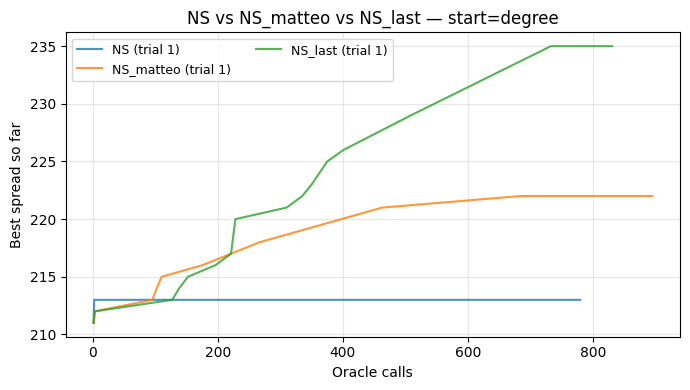

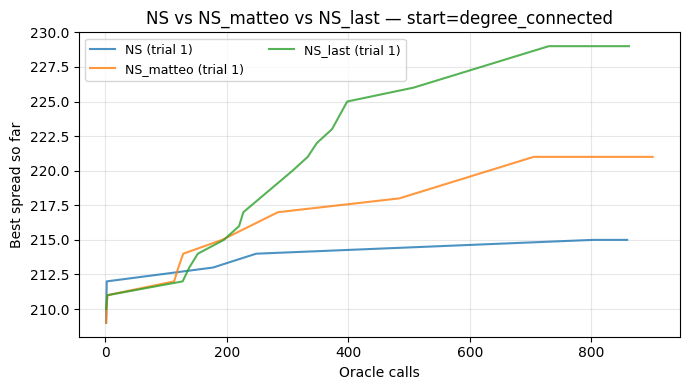

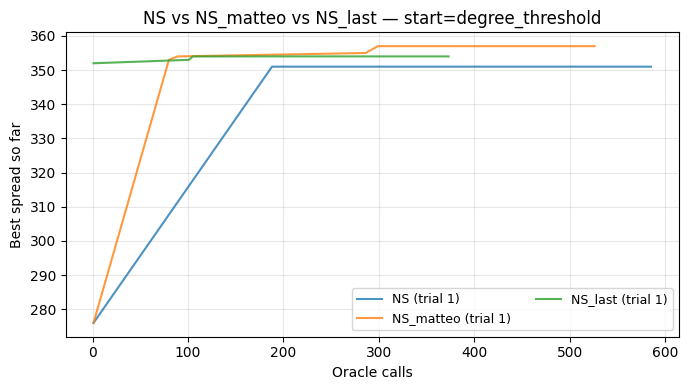

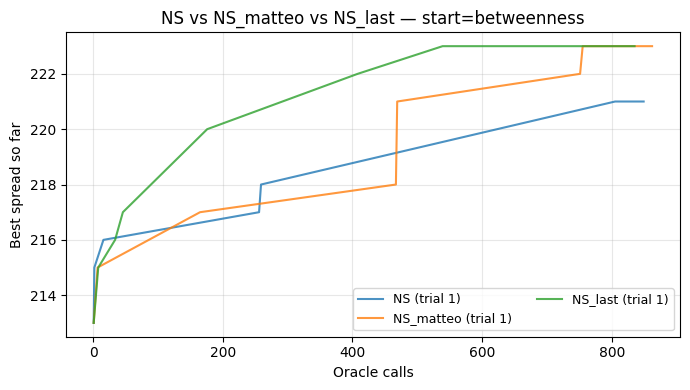

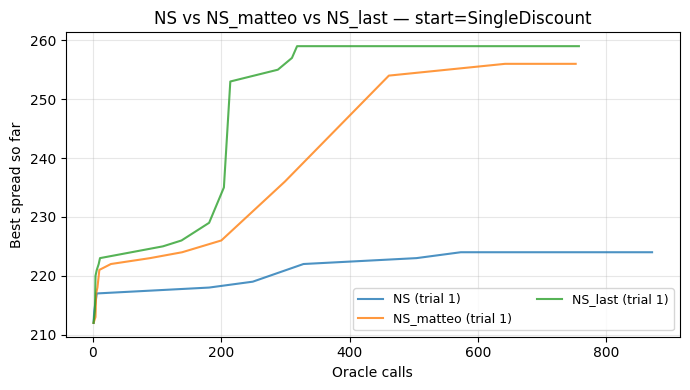

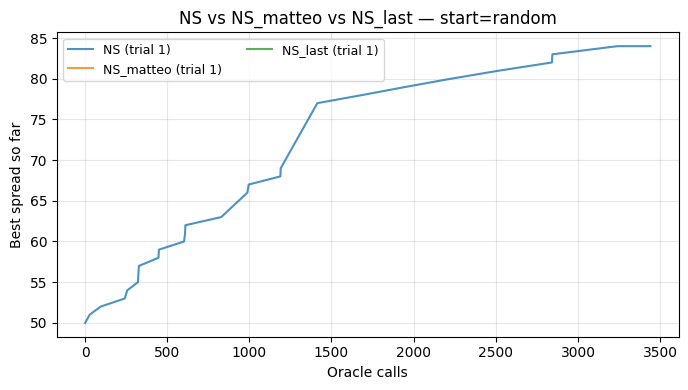

✅ Plots saved in: /content/gdrive/MyDrive/influence_results/ns_vs_ns_last/2026-03-10_141248_N1000_c1_t60s


In [23]:
# ============================================================
# EXPERIMENT — NS vs NS_last vs NS_matteo
# start from: heuristics + random
# Save: Excel + plots to Google Drive
# ============================================================

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ---------------------------
# MOUNT DRIVE (SAFE)
# ---------------------------
from google.colab import drive
MOUNTPOINT = "/content/gdrive"
os.makedirs(MOUNTPOINT, exist_ok=True)
if not os.path.ismount(MOUNTPOINT):
    drive.mount(MOUNTPOINT, force_remount=True)

# ---------------------------
# SETTINGS
# ---------------------------
N = 1000
TRIALS = 1

RNG_SEED_GRAPH  = 42
RNG_SEED_TRIALS = 2026

C_THRESH = 1

# NS/NS_last/NS_matteo hyperparams
DELTA = 0.5
XI = 0.01
D = 2
MAX_TIME = 60
BUFFER_DIM = 5000

# NS_last
H_RADIUS = 30
MAX_OUTER_ITERS = 1000

# NS_matteo params (defaults from your signature; edit if you want)
MIN_CONN_MAT = 50
MG_MAX_DEPTH = 2
MG_SIZE = 20
MG_MEMORY_LEN = 5

# ---------------------------
# OUTPUT PATH ON DRIVE
# ---------------------------
RUN_ID = datetime.now().strftime("%Y-%m-%d_%H%M%S")
OUT_DIR = f"{MOUNTPOINT}/MyDrive/influence_results/ns_vs_ns_last/{RUN_ID}_N{N}_c{C_THRESH}_t{MAX_TIME}s"
os.makedirs(OUT_DIR, exist_ok=True)

out_xlsx = os.path.join(OUT_DIR, "results.xlsx")
print("✅ Output folder:", OUT_DIR)
print("✅ Excel:", out_xlsx)

# ---------------------------
# HELPERS
# ---------------------------
def history_to_df_general(history):
    arr = np.asarray(history, dtype=float)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    calls = arr[:, 2].astype(int)
    bests = arr[:, 0].astype(int)
    order = np.argsort(calls)
    calls = calls[order]
    bests = bests[order]
    return (
        pd.DataFrame({"calls": calls, "best_spread": bests})
          .groupby("calls", as_index=False)
          .last()
    )

def influence_eval_theta(g_local, x_vec, theta_vec):
    Wloc = np.zeros((g_local.number_of_nodes(), g_local.number_of_nodes()))
    spread, _, _ = Influence_evaluation_comp_threshold_theta(
        g_local, Wloc, x_vec, params=None, theta_vec=theta_vec, h0=1.0
    )
    return int(spread)

def x_random_init(n_nodes, K, rng):
    x = np.zeros(n_nodes, dtype=float)
    seeds = rng.choice(n_nodes, size=K, replace=False)
    x[seeds] = 1.0
    return x

# Bridge for NS_last internal call (se NS_last chiama influence_evaluation(g, x, theta))
def influence_evaluation(g_local, x_vec, theta_local):
    Wloc = np.zeros((g_local.number_of_nodes(), g_local.number_of_nodes()))
    return Influence_evaluation_comp_threshold_theta(
        g_local, Wloc, x_vec, params=None, theta_vec=theta_local, h0=1.0
    )

# ---------------------------
# BUILD GRAPH + THRESHOLDS
# ---------------------------
g = preferential_attachment_variable_m(
    N=N,
    seed=RNG_SEED_GRAPH,
    init_nodes=5,
    init_mode="complete",
    M=(1, 2, 3, 4),
)

theta_dict, allowed_values = assign_thresholds_paper_experiments(
    g, c=C_THRESH, seed=RNG_SEED_GRAPH, attr="theta"
)
theta_vec = np.array([theta_dict[i] for i in range(N)], dtype=int)

n_nodes = g.number_of_nodes()
n_edges = g.number_of_edges()
print(f"Graph built: N={n_nodes}, edges={n_edges}, c={C_THRESH}")

# ---------------------------
# DEFINE HEURISTICS (RETURN x0 VECTOR!)
# ---------------------------
K_SEEDS = 50

def h_degree():
    return degree(g, n_nodes, K_SEEDS, thetas=theta_dict, connected=0)

def h_degree_connected():
    return degree_connected(g, n_nodes, K_SEEDS, thetas=theta_dict, connected=None)

def h_degree_threshold():
    return degree_threshold(g, n_nodes, K_SEEDS, thetas=theta_dict, connected=0)

def h_betweenness():
    return betweenness(g, n_nodes, K_SEEDS, thetas=theta_dict, connected=0)

def h_single_discount():
    s, x = SingleDiscount(g, theta_vec, K_SEEDS)
    return x

HEURISTICS = {
    "degree": h_degree,
    "degree_connected": h_degree_connected,
    "degree_threshold": h_degree_threshold,
    "betweenness": h_betweenness,
    "SingleDiscount": h_single_discount,
    "random": None,   # gestito a parte
}

print("Heuristics:", list(HEURISTICS.keys()))
print(f"K_SEEDS={K_SEEDS} | MAX_TIME={MAX_TIME}s")

# ---------------------------
# RUN EXPERIMENTS
# ---------------------------
base_rng = np.random.default_rng(RNG_SEED_TRIALS)

rows_summary = []
rows_history_long = []

# per i plot: dict[(heuristic, solver, trial)] -> df(calls,best)
plot_store = {}

for t in range(1, TRIALS + 1):
    trial_seed = int(base_rng.integers(0, 10**9))
    rng_trial = np.random.default_rng(trial_seed)

    for hname, hfn in HEURISTICS.items():

        # ---- build x0 from heuristic (or random) ----
        if hname == "random":
            x0 = x_random_init(n_nodes, K_SEEDS, rng_trial)
        else:
            x0 = hfn()

        # baseline heuristic spread (IDENTICO A PRIMA)
        spread_h = influence_eval_theta(g, x0, theta_vec)

        rows_history_long.append({
            "run_id": RUN_ID,
            "trial": int(t),
            "start": hname,
            "method": f"{hname} (heur)",
            "calls": 1,
            "best_spread": int(spread_h),
            "N": int(n_nodes),
            "E": int(n_edges),
            "C_THRESH": int(C_THRESH),
            "K": int(K_SEEDS),
            "trial_seed": int(trial_seed),
        })

        # ==========================
        # NS
        # ==========================
        s_ns, X_ns, hist_ns = NS_solver(
            g, theta_dict, x0,
            DELTA, XI, D, MAX_TIME, BUFFER_DIM,
            verbose=0
        )

        df_ns = history_to_df_general(hist_ns)
        best_ns = int(max(s_ns)) if len(s_ns) else int(df_ns["best_spread"].max() if len(df_ns) else 0)
        ns_calls = int(df_ns["calls"].iloc[-1]) if len(df_ns) else 0

        for _, r in df_ns.iterrows():
            rows_history_long.append({
                "run_id": RUN_ID,
                "trial": int(t),
                "start": hname,
                "method": f"NS(start={hname})",
                "calls": int(r["calls"]),
                "best_spread": int(r["best_spread"]),
                "N": int(n_nodes),
                "E": int(n_edges),
                "C_THRESH": int(C_THRESH),
                "K": int(K_SEEDS),
                "trial_seed": int(trial_seed),
            })

        plot_store[(hname, "NS", t)] = df_ns

        # ==========================
        # NS_matteo
        # ==========================
        s_mat, X_mat, hist_mat = NS_matteo(
            g,
            theta_dict,
            x0,
            DELTA,
            XI,
            D,
            MAX_TIME,
            BUFFER_DIM,
            verbose=0,
            min_conn=MIN_CONN_MAT,
            mg_max_depth=MG_MAX_DEPTH,
            mg_size=MG_SIZE,
            mg_memory_len=MG_MEMORY_LEN,
        )

        df_mat = history_to_df_general(hist_mat)
        best_mat = int(max(s_mat)) if len(s_mat) else int(df_mat["best_spread"].max() if len(df_mat) else 0)
        mat_calls = int(df_mat["calls"].iloc[-1]) if len(df_mat) else 0

        for _, r in df_mat.iterrows():
            rows_history_long.append({
                "run_id": RUN_ID,
                "trial": int(t),
                "start": hname,
                "method": f"NS_matteo(start={hname})",
                "calls": int(r["calls"]),
                "best_spread": int(r["best_spread"]),
                "N": int(n_nodes),
                "E": int(n_edges),
                "C_THRESH": int(C_THRESH),
                "K": int(K_SEEDS),
                "trial_seed": int(trial_seed),
            })

        plot_store[(hname, "NS_matteo", t)] = df_mat

        # ==========================
        # NS_last
        # ==========================
        s_last, X_last, hist_last = NS_last(
            g,
            x0,
            theta_vec,
            d=D,
            max_time=MAX_TIME,
            buffer_dim=BUFFER_DIM,
            max_outer_iters=MAX_OUTER_ITERS,
            early_stop_spread=None,
            H_RADIUS=H_RADIUS,
        )

        df_last = history_to_df_general(hist_last)
        best_last = int(max(s_last)) if len(s_last) else int(df_last["best_spread"].max() if len(df_last) else 0)
        last_calls = int(df_last["calls"].iloc[-1]) if len(df_last) else 0

        for _, r in df_last.iterrows():
            rows_history_long.append({
                "run_id": RUN_ID,
                "trial": int(t),
                "start": hname,
                "method": f"NS_last(start={hname})",
                "calls": int(r["calls"]),
                "best_spread": int(r["best_spread"]),
                "N": int(n_nodes),
                "E": int(n_edges),
                "C_THRESH": int(C_THRESH),
                "K": int(K_SEEDS),
                "trial_seed": int(trial_seed),
            })

        plot_store[(hname, "NS_last", t)] = df_last

        # summary row (IDENTICA struttura + NS_matteo in più)
        rows_summary.append({
            "run_id": RUN_ID,
            "trial": int(t),
            "start_heuristic": hname,
            "heur_spread": int(spread_h),

            "NS_best_spread": int(best_ns),
            "NS_calls": int(ns_calls),

            "NS_matteo_best_spread": int(best_mat),
            "NS_matteo_calls": int(mat_calls),

            "NS_last_best_spread": int(best_last),
            "NS_last_calls": int(last_calls),

            "N": int(n_nodes),
            "E": int(n_edges),
            "C_THRESH": int(C_THRESH),
            "K": int(K_SEEDS),
            "trial_seed": int(trial_seed),
        })

# ---------------------------
# SAVE EXCEL
# ---------------------------
df_summary = pd.DataFrame(rows_summary)
df_hist = pd.DataFrame(rows_history_long)

with pd.ExcelWriter(out_xlsx, engine="openpyxl", mode="w") as writer:
    df_summary.to_excel(writer, sheet_name="summary", index=False)
    df_hist.to_excel(writer, sheet_name="history_long", index=False)

print("✅ Saved:", out_xlsx)
display(df_summary.head(20))

# ---------------------------
# PLOTS: one figure per heuristic (overlay TRIALS)
# ---------------------------
heur_list = list(HEURISTICS.keys())
for hname in heur_list:
    fig, ax = plt.subplots(figsize=(7, 4))

    for t in range(1, TRIALS + 1):
        df_ns   = plot_store.get((hname, "NS", t), None)
        df_mat  = plot_store.get((hname, "NS_matteo", t), None)
        df_last = plot_store.get((hname, "NS_last", t), None)

        if df_ns is not None and len(df_ns):
            ax.plot(df_ns["calls"], df_ns["best_spread"], linewidth=1.5, alpha=0.8,
                    label=f"NS (trial {t})")
        if df_mat is not None and len(df_mat):
            ax.plot(df_mat["calls"], df_mat["best_spread"], linewidth=1.5, alpha=0.8,
                    label=f"NS_matteo (trial {t})")
        if df_last is not None and len(df_last):
            ax.plot(df_last["calls"], df_last["best_spread"], linewidth=1.5, alpha=0.8,
                    label=f"NS_last (trial {t})")

    ax.set_title(f"NS vs NS_matteo vs NS_last — start={hname}")
    ax.set_xlabel("Oracle calls")
    ax.set_ylabel("Best spread so far")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()

    plot_path = os.path.join(OUT_DIR, f"plot_NS_vs_NS_matteo_vs_NS_last__start_{hname}.png")
    fig.savefig(plot_path, dpi=180)
    plt.show()

print("✅ Plots saved in:", OUT_DIR)